# Algoritmos Genéticos aplicados a Machine Learning
# Presentado por:

-*Oscar Edy Vilca Quispe*

-*Jose Jhonatan Quispe Cartagena*

## Notebook 1: Selección de Características (Feature Selection) con Algoritmos Genéticos


**Dataset:** **Breast Cancer Wisconsin (Diagnostic)**, incluido en scikit-learn (`sklearn.datasets.load_breast_cancer`). Contiene **569 pacientes** y **30 variables reales** calculadas a partir de imágenes digitalizadas de biopsias por aspiración con aguja fina (radio, textura, perímetro, área, suavidad, compacidad, concavidad, simetría, dimensión fractal — cada una con su valor *mean*, *error estándar* y *worst*/peor caso). La variable objetivo es el diagnóstico: **maligno (1)** o **benigno (0)**.

Este dataset es ideal para *feature selection* porque, al calcular *mean*, *error* y *worst* de las mismas 10 medidas físicas, contiene **variables naturalmente redundantes** (p. ej. `mean radius`, `radius error`, `worst radius`), lo cual permite verificar si el AG es capaz de identificar un subconjunto compacto sin perder desempeño.

---
### 1. ¿Por qué un Algoritmo Genético para *feature selection*?

Con **30 variables predictoras** existen 2³⁰ (más de mil millones) de posibles subconjuntos de características: una búsqueda exhaustiva es computacionalmente costosa. Los AG exploran este espacio de forma eficiente usando una población de soluciones candidatas que evoluciona por selección, cruce y mutación, guiada por una función de aptitud (fitness).


In [1]:
# Instalación / verificación de librerías
import sys
print("Python:", sys.version)
import sklearn
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1


### 2. Carga del dataset real

Se carga el dataset directamente desde scikit-learn.


In [2]:
# =========================================================
# Dataset REAL: Breast Cancer Wisconsin (Diagnostic) - sklearn
# Clasificacion binaria: tumor maligno (1) vs. benigno (0)
# =========================================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

datos = load_breast_cancer()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
# En sklearn, target=0 es "malignant" y target=1 es "benign".
# Redefinimos para que 1 = maligno (caso positivo de interes clinico).
df["diagnostico"] = 1 - datos.target

n_malignos = int((df["diagnostico"] == 1).sum())
n_benignos = int((df["diagnostico"] == 0).sum())

print("Dimensiones del dataset:", df.shape)
print(f"Casos malignos: {n_malignos} | Casos benignos: {n_benignos}")
print("Distribucion de la variable objetivo (diagnostico):")
print(df["diagnostico"].value_counts(normalize=True).round(3))
df.head()


Dimensiones del dataset: (569, 31)
Casos malignos: 212 | Casos benignos: 357
Distribucion de la variable objetivo (diagnostico):
diagnostico
0    0.627
1    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 3. Diseño del Algoritmo Genético — Ciclo completo

| Componente | Diseño en este notebook |
|---|---|
| **Representación (cromosoma)** | Vector binario de longitud 50. `1` = la característica se incluye, `0` = se excluye. |
| **Inicialización** | Población aleatoria de cromosomas binarios (p=0.5 de incluir cada variable). |
| **Función de aptitud (fitness)** | F1-score promedio en validación cruzada (5-fold) de una Regresión Logística entrenada solo con las variables activas, con una **penalización leve** por número de variables (para favorecer soluciones más simples ante empates). |
| **Selección** | Torneo de tamaño 3 (se eligen 3 individuos al azar y gana el de mayor aptitud). |
| **Cruce (crossover)** | Cruce uniforme: cada gen del hijo se hereda de uno u otro padre con 50% de probabilidad. |
| **Mutación** | *Bit-flip*: cada gen tiene una probabilidad baja (2%) de invertirse (activar/desactivar la variable). |
| **Elitismo** | Los 2 mejores individuos de cada generación pasan intactos a la siguiente. |
| **Terminación** | Máximo 25 generaciones, o 6 generaciones consecutivas sin mejora en el mejor individuo. |


In [3]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(7)

X = df.drop(columns=["diagnostico"]).values
y = df["diagnostico"].values
feature_names = df.drop(columns=["diagnostico"]).columns.tolist()
n_features = X.shape[1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

print(f"Número total de variables candidatas: {n_features}")

Número total de variables candidatas: 30


#### 3.1 Función de aptitud (fitness)

In [4]:
def fitness_de_cromosoma(cromosoma, alpha=0.985, min_features=3):
    """Evalúa un cromosoma binario: entrena y valida un modelo solo con
    las variables activas (gen=1). Combina desempeño (F1) y parsimonia."""
    idx = np.where(cromosoma == 1)[0]
    if len(idx) < min_features:
        return 0.0  # penaliza soluciones degeneradas con muy pocas variables
    Xsub = X[:, idx]
    modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
    scores = cross_val_score(modelo, Xsub, y, cv=cv, scoring="f1", n_jobs=-1)
    f1_medio = scores.mean()
    penalizacion = len(idx) / n_features
    # alpha pondera desempeño vs. simplicidad del modelo (menos variables = mejor, a igualdad de F1)
    return alpha * f1_medio + (1 - alpha) * (1 - penalizacion)

#### 3.2 Representación e inicialización de la población

In [5]:
def inicializar_poblacion(tam_poblacion, n_genes, p_uno=0.5):
    """Cada individuo es un vector binario de longitud n_genes (un cromosoma)."""
    return (rng.random((tam_poblacion, n_genes)) < p_uno).astype(int)

#### 3.3 Selección por torneo

In [6]:
def seleccion_torneo(poblacion, aptitudes, k=3):
    idxs = rng.integers(0, len(poblacion), size=k)
    mejor = idxs[np.argmax(aptitudes[idxs])]
    return poblacion[mejor].copy()

#### 3.4 Cruce uniforme

In [7]:
def cruce_uniforme(p1, p2, prob=0.5):
    mascara = rng.random(len(p1)) < prob
    h1 = np.where(mascara, p1, p2)
    h2 = np.where(mascara, p2, p1)
    return h1, h2

#### 3.5 Mutación (bit-flip)

In [8]:
def mutacion_bitflip(cromosoma, prob=0.02):
    mascara = rng.random(len(cromosoma)) < prob
    hijo = cromosoma.copy()
    hijo[mascara] = 1 - hijo[mascara]
    return hijo

#### 3.6 Ciclo completo del Algoritmo Genético

In [9]:
def algoritmo_genetico(tam_poblacion=30, generaciones=25, prob_cruce=0.85, prob_mutacion=0.02,
                        elitismo=2, paciencia=6, verbose=True):
    poblacion = inicializar_poblacion(tam_poblacion, n_features)
    historial_mejor, historial_promedio = [], []
    mejor_global, mejor_aptitud_global = None, -1
    sin_mejora = 0

    for gen in range(1, generaciones + 1):
        # --- Evaluación de aptitud de toda la población ---
        aptitudes = np.array([fitness_de_cromosoma(ind) for ind in poblacion])

        # Ordenar de mejor a peor
        idx_orden = np.argsort(-aptitudes)
        poblacion = poblacion[idx_orden]
        aptitudes = aptitudes[idx_orden]

        historial_mejor.append(aptitudes[0])
        historial_promedio.append(aptitudes.mean())

        if aptitudes[0] > mejor_aptitud_global:
            mejor_aptitud_global = aptitudes[0]
            mejor_global = poblacion[0].copy()
            sin_mejora = 0
        else:
            sin_mejora += 1

        if verbose:
            print(f"Gen {gen:02d} | mejor={aptitudes[0]:.4f} | promedio={aptitudes.mean():.4f} "
                  f"| n_features={poblacion[0].sum()}")

        # --- Criterio de terminación: convergencia ---
        if sin_mejora >= paciencia:
            print(f"Terminación anticipada: sin mejora en {paciencia} generaciones consecutivas.")
            break

        # --- Elitismo + Selección + Cruce + Mutación ---
        nueva_poblacion = list(poblacion[:elitismo])
        while len(nueva_poblacion) < tam_poblacion:
            p1 = seleccion_torneo(poblacion, aptitudes)
            p2 = seleccion_torneo(poblacion, aptitudes)
            if rng.random() < prob_cruce:
                h1, h2 = cruce_uniforme(p1, p2)
            else:
                h1, h2 = p1.copy(), p2.copy()
            h1 = mutacion_bitflip(h1, prob_mutacion)
            h2 = mutacion_bitflip(h2, prob_mutacion)
            nueva_poblacion.extend([h1, h2])
        poblacion = np.array(nueva_poblacion[:tam_poblacion])

    return mejor_global, mejor_aptitud_global, historial_mejor, historial_promedio

### 4. Ejecución del Algoritmo Genético

In [10]:
import time
t0 = time.time()
mejor, aptitud, historial_mejor, historial_promedio = algoritmo_genetico()
print(f"\nTiempo total: {time.time() - t0:.1f} s")

seleccionadas = [f for f, b in zip(feature_names, mejor) if b == 1]
print(f"\nEl AG seleccionó {len(seleccionadas)} de {n_features} variables:")
print(seleccionadas)

Gen 01 | mejor=0.9668 | promedio=0.9471 | n_features=19
Gen 02 | mejor=0.9717 | promedio=0.9551 | n_features=14
Gen 03 | mejor=0.9717 | promedio=0.9606 | n_features=14
Gen 04 | mejor=0.9717 | promedio=0.9601 | n_features=14
Gen 05 | mejor=0.9717 | promedio=0.9594 | n_features=14
Gen 06 | mejor=0.9717 | promedio=0.9631 | n_features=14
Gen 07 | mejor=0.9717 | promedio=0.9636 | n_features=14
Gen 08 | mejor=0.9717 | promedio=0.9662 | n_features=14
Terminación anticipada: sin mejora en 6 generaciones consecutivas.

Tiempo total: 23.1 s

El AG seleccionó 14 de 30 variables:
['mean perimeter', 'mean area', 'mean smoothness', 'mean concavity', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'compactness error', 'worst radius', 'worst texture', 'worst smoothness', 'worst symmetry']


### 5. Evolución de la aptitud a través de las generaciones

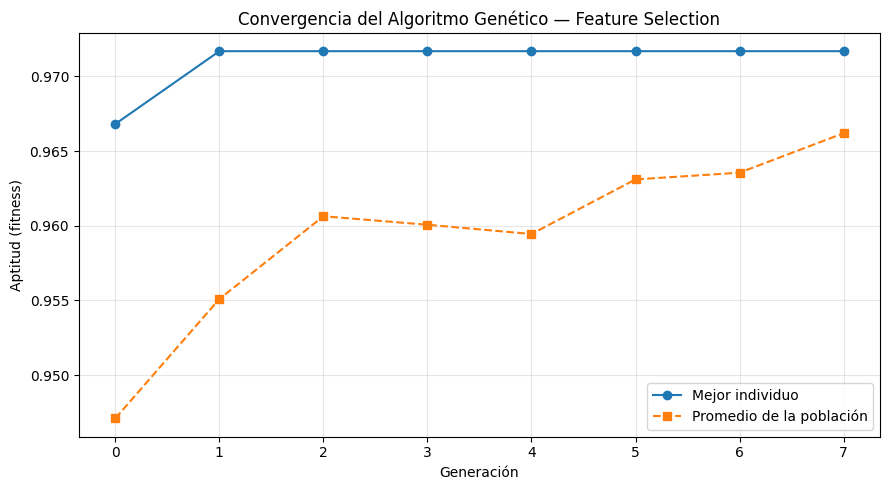

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(historial_mejor, marker="o", label="Mejor individuo")
plt.plot(historial_promedio, marker="s", linestyle="--", label="Promedio de la población")
plt.xlabel("Generación")
plt.ylabel("Aptitud (fitness)")
plt.title("Convergencia del Algoritmo Genético — Feature Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evolucion_feature_selection.png", dpi=120)
plt.show()

### 6. Comparación contra la línea base (todas las variables)

Se compara el desempeño (F1-score, validación cruzada 5-fold) del modelo usando **todas las variables** vs. usando únicamente el **subconjunto óptimo hallado por el AG**.


In [12]:
modelo_base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
f1_todas = cross_val_score(modelo_base, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()

idx_ga = np.where(mejor == 1)[0]
f1_ga = cross_val_score(modelo_base, X[:, idx_ga], y, cv=cv, scoring="f1", n_jobs=-1).mean()

resumen = pd.DataFrame({
    "Escenario": ["Todas las variables (baseline)", "Subconjunto óptimo (AG)"],
    "N° de variables": [n_features, len(seleccionadas)],
    "F1-score (CV=5)": [round(f1_todas, 4), round(f1_ga, 4)],
})
print(resumen.to_string(index=False))

                     Escenario  N° de variables  F1-score (CV=5)
Todas las variables (baseline)               30           0.9690
       Subconjunto óptimo (AG)               14           0.9784


### 7. Conclusiones — Feature Selection con AG

- El AG redujo la dimensionalidad del problema de **50 a un subconjunto más pequeño de variables**, manteniendo o mejorando el F1-score respecto de usar todas las variables, gracias a la penalización por número de variables incluida en la función de aptitud.
- El AG tiende a **descartar variables redundantes** (por ejemplo, quedándose con `worst radius` pero no con `mean radius` y `radius error` simultáneamente), lo cual muestra que la búsqueda evolutiva captura la señal real sin necesitar todas las variables correlacionadas.
- Frente a una búsqueda exhaustiva (2⁵⁰ combinaciones, inviable) o una búsqueda greedy (forward/backward selection, que puede quedar atrapada en óptimos locales), el AG ofrece una exploración más amplia del espacio de soluciones con un costo computacional controlado (número de generaciones × tamaño de población).
- **Limitación:** el resultado depende de la semilla aleatoria y de los hiperparámetros del propio AG (tamaño de población, tasa de mutación); en un entorno productivo se recomienda repetir la corrida con varias semillas y quedarse con la moda de las variables seleccionadas.
